In [ ]:
import os
import sys
from pathlib import Path
os.environ['OMP_NUM_THREADS'] = '4'

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "models").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
PROJECT_ROOT = PROJECT_ROOT.resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openai
import dotenv

dotenv.load_dotenv()
openai.api_key = os.environ['OPENAI_API_KEY']
openai.api_base = os.environ.get("OPENAI_API_BASE", "https://api.openai.com/v1")
from data.serialize import SerializerSettings, serialize_arr
from models.utils import grid_iter
from models.promptcast import get_promptcast_predictions_data
from models.darts import get_arima_predictions_data
from models.llmtime import get_llmtime_predictions_data, get_scaler
from data.small_context import get_datasets
from models.validation_likelihood_tuning import get_autotuned_predictions_data
from loguru import logger

%load_ext autoreload
%autoreload 2

def plot_preds(train, test, pred_dict, model_name, show_samples=False):
    pred = pred_dict['median']
    pred = pd.Series(pred, index=test.index)
    plt.figure(figsize=(8, 6), dpi=100)
    plt.plot(train)
    plt.plot(test, label='Truth', color='black')
    plt.plot(pred, label=model_name, color='purple')
    # shade 90% confidence interval
    samples = pred_dict['samples']
    lower = np.quantile(samples, 0.05, axis=0)
    upper = np.quantile(samples, 0.95, axis=0)
    plt.fill_between(pred.index, lower, upper, alpha=0.3, color='purple')
    if show_samples:
        samples = pred_dict['samples']
        # convert df to numpy array
        samples = samples.values if isinstance(samples, pd.DataFrame) else samples
        for i in range(min(10, samples.shape[0])):
            plt.plot(pred.index, samples[i], color='purple', alpha=0.3, linewidth=1)
    plt.legend(loc='upper left')
    if 'NLL/D' in pred_dict:
        nll = pred_dict['NLL/D']
        if nll is not None:
            plt.text(0.03, 0.85, f'NLL/D: {nll:.2f}', transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.5))
    plt.show()

/home/amir/miniconda3/envs/llmtime/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Define models ##

In [2]:
gpt4_hypers = dict(
    alpha=0.3,
    basic=True,
    temp=1.0,
    top_p=0.8,
    settings=SerializerSettings(base=10, prec=3, signed=True, time_sep=', ', bit_sep='', minus_sign='-')
)

gpt3_hypers = dict(
    temp=0.7,
    alpha=0.95,
    beta=0.3,
    basic=False,
    settings=SerializerSettings(base=10, prec=3, signed=True, half_bin_correction=True)
)


promptcast_hypers = dict(
    temp=0.7,
    settings=SerializerSettings(base=10, prec=0, signed=True, 
                                time_sep=', ',
                                bit_sep='',
                                plus_sign='',
                                minus_sign='-',
                                half_bin_correction=False,
                                decimal_point='')
)

arima_hypers = dict(p=[12,30], d=[1,2], q=[0])

model_hypers = {
    # 'LLMTime GPT-3.5': {'model': 'gpt-3.5-turbo-instruct', **gpt3_hypers},
    'LLMTime GPT-4': {'model': 'gpt-4', **gpt4_hypers},
    # 'LLMTime GPT-3': {'model': 'text-davinci-003', **gpt3_hypers},
    # 'PromptCast GPT-3': {'model': 'text-davinci-003', **promptcast_hypers},
    # 'ARIMA': arima_hypers,
    
}

model_predict_fns = {
    # 'LLMTime GPT-3': get_llmtime_predictions_data,
    'LLMTime GPT-4': get_llmtime_predictions_data,
    # 'PromptCast GPT-3': get_promptcast_predictions_data,
    # 'ARIMA': get_arima_predictions_data,
}

model_names = list(model_predict_fns.keys())

In [3]:
# gptoss_hypers = dict(
#     alpha=0.3,
#     basic=True,
#     temp=1.0,
#     top_p=0.8,
#     settings=SerializerSettings(base=10, prec=3, signed=True, time_sep=',', bit_sep='', minus_sign='-')
# )

# model_hypers = {
#    'gpt-oss': {'model': 'gpt-oss', **gptoss_hypers},
# }

# model_predict_fns = {
#     'gpt-oss': get_llmtime_predictions_data,
# }

# model_names = list(model_predict_fns.keys())

In [4]:
# gemma_hypers = dict(
#     alpha=0.3,
#     basic=True,
#     temp=1.0,
#     top_p=0.8,
#     settings=SerializerSettings(base=10, prec=3, signed=True, time_sep=',', bit_sep='', minus_sign='-')
# )

# model_hypers = {
#    'gemma-12b': {'model': 'gemma-12b', **gemma_hypers},
# }

# model_predict_fns = {
#     'gemma-12b': get_llmtime_predictions_data,
# }

# model_names = list(model_predict_fns.keys())

In [5]:
# qwen_hypers = dict(
#     alpha=0.3,
#     basic=True,
#     temp=1.0,
#     top_p=0.8,
#     settings=SerializerSettings(base=10, prec=3, signed=True, time_sep=',', bit_sep='', minus_sign='-')
# )

# model_hypers = {
#    'qwen-30b': {'model': 'qwen-30b', **qwen_hypers},
# }

# model_predict_fns = {
#     'qwen-30b': get_llmtime_predictions_data,
# }

# model_names = list(model_predict_fns.keys())

In [6]:
datasets = get_datasets()
ds_name = 'AirPassengersDataset'

data = datasets[ds_name]
train, test = data # or change to your own data

## Get results from Chronos ##

In [7]:
from models.chronos_forecast import get_predictions_chronos
import torch


quantiles, median = get_predictions_chronos(
    input_tensor=torch.tensor(train.values),
    prediction_length=29,
    quantiles=[0.1, 0.5, 0.9]
)

`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!


In [8]:
median

tensor([[477.2699, 430.3739, 358.6089, 342.9769, 363.5827, 374.9514, 388.4517,
         411.8997, 419.7157, 428.9528, 471.5855, 515.6393, 512.7971, 474.4277,
         404.7943, 382.7674, 394.1361, 405.5048, 419.0052, 433.2161, 436.0583,
         443.1637, 497.1651, 542.6400, 535.5345, 494.3229, 426.1106, 409.7681,
         427.5317]])

## Running LLMTime and Visualizing Results ##

In [9]:
chatgpt_sys_message = '''
You are a helpful assistant that performs time series predictions. The user will provide a sequence and you will predict the remaining sequence. The sequence is represented by decimal strings separated by commas.
'''

extra_input = '''
Note: Please continue the following sequence without producing any additional text. Do not say anything like 'the next terms in the sequence are', JUST return the numbers. Sequence:
'''

2025-09-18 12:19:08.934 | DEBUG    | models.llmtime:get_llmtime_predictions_data:226 - Transformed medians: [array([[2.67527952, 2.41240976, 2.01013933, 1.92251607, 2.03801946,
        2.10174543, 2.17741996, 2.30885493, 2.35266647, 2.40444406,
        2.64341654, 2.89035472, 2.87442331, 2.65934794, 2.26902607,
        2.14555715, 2.20928312, 2.27300909, 2.34868379, 2.42834117,
        2.44427275, 2.48410144, 2.78679989, 3.04170412, 3.00187526,
        2.77086848, 2.38851248, 2.2969062 , 2.39647818]])]
2025-09-18 12:19:08.935 | DEBUG    | models.llmtime:get_llmtime_predictions_data:227 - Transformed medians shape: [(1, 29)]
2025-09-18 12:19:08.938 | DEBUG    | models.llmtime:get_llmtime_predictions_data:234 - Medians that are added to the extra input: 2675, 2412, 2010, 1922, 2038, 2101, 2177, 2308, 2352, 2404, 2643, 2890, 2874, 2659, 2269, 2145, 2209, 2273, 2348, 2428, 2444, 2484, 2786, 3041, 3001, 2770, 2388, 2296, 2396, 


Sampling with best hyper... defaultdict(<class 'dict'>, {'model': 'gpt-4', 'alpha': 0.3, 'basic': True, 'temp': 1.0, 'top_p': 0.8, 'settings': SerializerSettings(base=10, prec=3, signed=True, fixed_length=False, max_val=10000000.0, time_sep=', ', bit_sep='', plus_sign='', minus_sign='-', half_bin_correction=True, decimal_point='', missing_str=' Nan'), 'dataset_name': 'AirPassengersDataset'}) 
 with NLL inf


  0%|          | 0/1 [00:00<?, ?it/s]

2025-09-18 12:19:09.095 | DEBUG    | models.gpt:gpt_completion_fn:80 - sys_message: 
You are a helpful assistant that performs time series predictions. The user will provide a sequence and you will predict the remaining sequence. The sequence is represented by decimal strings separated by commas.

2025-09-18 12:19:09.096 | DEBUG    | models.gpt:gpt_completion_fn:81 - user_message: The following sequence is a set of predicted values generated by another forecasting model. These values are not actual observations but reflect the model’s estimation of the future behavior of the time series. You may consider this as an external opinion or auxiliary input to support your own prediction. The number of steps you separate using ,  should be 29.
2675, 2412, 2010, 1922, 2038, 2101, 2177, 2308, 2352, 2404, 2643, 2890, 2874, 2659, 2269, 2145, 2209, 2273, 2348, 2428, 2444, 2484, 2786, 3041, 3001, 2770, 2388, 2296, 2396, 
Note: Please continue the following sequence without producing any additional 

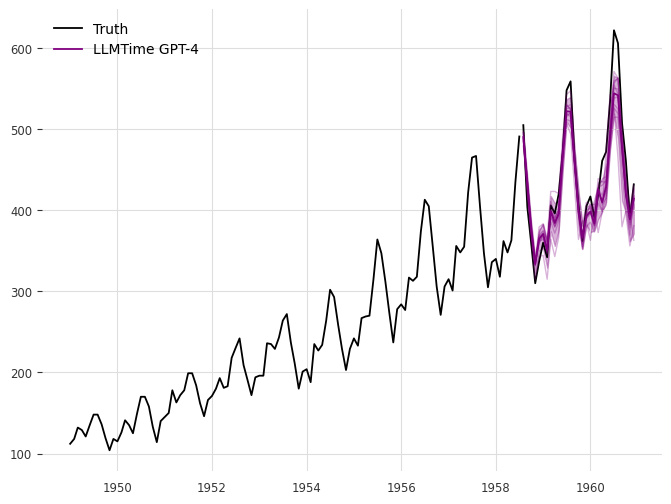

In [10]:
out = {}
for model in model_names: # GPT-4 takes a about a minute to run
    
    # serializer_setting = model_hypers[model].get('settings', None)
    # scaler = get_scaler(
    #     median.cpu().numpy().squeeze(), 
    #     alpha=model_hypers['LLMTime GPT-4'].get('alpha', 0.95),
    #     beta=model_hypers['LLMTime GPT-4'].get('beta', 0.3),
    #     basic=model_hypers['LLMTime GPT-4'].get('basic', False)
    # )
    # transformed_input_arrs = np.array([scaler.transform(median.cpu().numpy().squeeze())])

    # serialized_median = serialize_arr(transformed_input_arrs.squeeze(), settings=serializer_setting)
    
    # logger.debug(f"serialized_median: {serialized_median}")

    model_hypers[model].update({'dataset_name': ds_name}) # for promptcast
    hypers = list(grid_iter(model_hypers[model]))
    num_samples = 10

    pred_dict = get_autotuned_predictions_data(
        train,
        test,
        hypers,
        num_samples,
        model_predict_fns[model],
        verbose=False,
        parallel=False,
        chatgpt_sys_message=chatgpt_sys_message,
        extra_input=extra_input,
        few_shot_median=[median.cpu().numpy().squeeze()],
    )

    out[model] = pred_dict
    plot_preds(train, test, pred_dict, model, show_samples=True)

In [11]:
train

Month
1949-01-01    112.0
1949-02-01    118.0
1949-03-01    132.0
1949-04-01    129.0
1949-05-01    121.0
              ...  
1958-03-01    362.0
1958-04-01    348.0
1958-05-01    363.0
1958-06-01    435.0
1958-07-01    491.0
Freq: MS, Name: #Passengers, Length: 115, dtype: float64

In [12]:
pred_dict['samples']

Month,1958-08-01,1958-09-01,1958-10-01,1958-11-01,1958-12-01,1959-01-01,1959-02-01,1959-03-01,1959-04-01,1959-05-01,...,1960-03-01,1960-04-01,1960-05-01,1960-06-01,1960-07-01,1960-08-01,1960-09-01,1960-10-01,1960-11-01,1960-12-01
0,497.2900,441.2724,386.3252,341.1900,369.9124,374.9076,358.6732,400.4188,390.6068,403.0948,...,408.9820,398.8132,405.9492,471.6004,514.7732,514.7732,450.7276,395.4236,355.9972,381.1516
1,496.0412,434.3148,378.4756,335.6596,379.3676,383.2924,359.9220,410.7660,391.4988,399.5268,...,427.3572,406.4844,414.8692,499.2524,554.5564,543.3172,476.0604,413.6204,369.3772,417.0100
2,493.1868,431.8172,376.3348,331.5564,360.8140,370.4476,346.7204,399.8836,379.5460,389.1796,...,427.3572,438.4180,441.6292,485.3372,530.8292,524.9420,470.1732,419.8644,392.3908,412.5500
3,495.3276,440.0236,383.1140,337.6220,367.2364,371.1612,349.2180,393.2828,379.1892,394.1748,...,425.2164,411.1228,426.1084,501.2148,559.5516,562.2276,499.2524,442.1644,400.0620,431.1036
4,488.5484,433.9580,380.6164,336.0164,362.0628,368.6636,348.6828,391.8556,380.6164,394.8884,...,426.1084,418.4372,431.9956,510.8484,571.1476,563.1196,493.7220,430.3900,394.1748,424.6812
5,486.2292,426.2868,373.6588,334.4108,367.9500,373.6588,364.9172,423.2540,423.2540,420.5780,...,439.1316,435.0284,435.0284,491.0460,556.6972,563.2980,487.6564,433.9580,385.0764,406.8412
6,484.8020,422.7188,374.7292,331.5564,359.2084,367.5932,346.5420,386.1468,371.6964,386.1468,...,416.2964,398.9916,416.2964,480.5204,538.1436,540.2844,478.3796,420.2212,378.4756,403.9868
7,490.1540,436.8124,371.1612,333.1620,362.0628,364.0252,352.4292,399.7052,388.1092,396.8508,...,422.0052,408.6252,422.0052,491.7596,550.4532,549.5612,484.0884,422.0052,382.0436,417.9020
8,479.6284,428.2492,375.2644,332.8052,372.4100,382.7572,358.8516,398.4564,387.9308,401.3108,...,428.4276,430.9252,436.4556,482.8396,526.0124,519.2332,476.9524,417.9020,400.0620,415.7612
9,490.3324,419.6860,362.0628,314.9652,342.9740,344.4012,314.9652,364.0252,342.9740,366.5228,...,372.4100,397.7428,473.2060,542.6036,524.9420,464.9996,379.7244,399.3484,395.9588,362.9548
